# **EDA y visualizaciones**

## 1. Setup


In [ ]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización estática
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización interactiva (mapas y dispersiones)
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Estadísticos robustos
from scipy import stats

# Misc
import warnings
warnings.filterwarnings('ignore')

# Configuración estética
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'
PALETA = sns.color_palette('viridis', 8)
COLOR_VENTAS = '#1f77b4'
COLOR_ALQ    = '#d62728'

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

## 2. Carga de los datasets

In [ ]:
URL_ALQ    = 'https://raw.githubusercontent.com/kiaranatale/Trabajo-Practico-Real-State-Analytics/refs/heads/main/Datos2/dataset_alquileres_features.csv'
URL_VENTAS = 'https://raw.githubusercontent.com/kiaranatale/Trabajo-Practico-Real-State-Analytics/refs/heads/main/Datos2/dataset_ventas_features.csv'

df_alquileres = pd.read_csv(URL_ALQ)
df_ventas     = pd.read_csv(URL_VENTAS)

print(f'Alquileres: {df_alquileres.shape[0]:,} filas × {df_alquileres.shape[1]} columnas')
print(f'Ventas:     {df_ventas.shape[0]:,} filas × {df_ventas.shape[1]} columnas')

Alquileres: 3,645 filas × 80 columnas
Ventas:     3,868 filas × 91 columnas


In [ ]:
# Vista rápida de columnas relevantes para el EDA
print('VENTAS — columnas clave:')
print([c for c in ['Precio_USD','Precio_ajustado_USD','Precio_m2_USD','Sup_Cubierta_m2',
                   'Renta_estimada_mensual_USD','Renta_m2_USD','Rentabilidad_bruta_anual',
                   'Rentabilidad_neta_anual','Payback_anios','Yield_gap_vs_bonos',
                   'Distancia_subte_km','Distancia_parque_km','Indice_amenities',
                   'Tipologia','A_estrenar','Zona_riesgo','confianza_renta','Comuna','Barrio'] if c in df_ventas.columns])
print()
print('ALQUILERES — columnas clave:')
print([c for c in ['Precio_USD','Renta_largo_mensual_USD','Renta_m2_USD','Sup_Cubierta_m2',
                   'Distancia_subte_km','Distancia_parque_km','Indice_amenities',
                   'Tipologia','A_estrenar','Zona_riesgo','Comuna','Barrio'] if c in df_alquileres.columns])

VENTAS — columnas clave:
['Precio_USD', 'Precio_ajustado_USD', 'Precio_m2_USD', 'Sup_Cubierta_m2', 'Renta_estimada_mensual_USD', 'Renta_m2_USD', 'Rentabilidad_bruta_anual', 'Rentabilidad_neta_anual', 'Payback_anios', 'Yield_gap_vs_bonos', 'Distancia_subte_km', 'Distancia_parque_km', 'Indice_amenities', 'Tipologia', 'A_estrenar', 'Zona_riesgo', 'confianza_renta', 'Comuna', 'Barrio']

ALQUILERES — columnas clave:
['Precio_USD', 'Renta_largo_mensual_USD', 'Renta_m2_USD', 'Sup_Cubierta_m2', 'Distancia_subte_km', 'Distancia_parque_km', 'Indice_amenities', 'Tipologia', 'A_estrenar', 'Zona_riesgo', 'Comuna', 'Barrio']


## 3. Filtrado por geolocalización (`geo_ok = True`)

En el paso anterior se construyó `geo_ok` que marca si la propiedad tiene latitud y longitud válidos tras la geocodificación contra el callejero oficial + la intersección espacial con polígonos de barrios. Para todo este EDA **descartamos las filas sin geolocalización** debido a:

1. **Coherencia espacial**: cualquier KPI agregado por comuna (precio mediano, liquidez, tasa de delitos) requiere comuna asignada. Mezclar filas sin comuna distorsiona los conteos por zona.
2. **Comparabilidad bivariada**: las distancias a subte y parque son `NaN` cuando no hay coordenadas; al excluirlas evitamos sesgos por *missingness* selectiva en los scatter plots.
3. **Trazabilidad**: documentamos cuántas filas se descartan antes de seguir, para que el lector pueda dimensionar el impacto.

El descarte sería problemático si afectara desproporcionadamente algún segmento del mercado. Reportamos el % de filas perdidas y su distribución por tipología/precio para verificarlo.

In [ ]:
# Diagnóstico previo al filtro
def diag_geo(df, nombre):
    print(f'=== {nombre} ===')
    print(f'  Total filas:        {len(df):,}')
    print(f'  geo_ok = True:      {df["geo_ok"].sum():,} ({df["geo_ok"].mean()*100:.1f}%)')
    print(f'  Comuna asignada:    {df["Comuna"].notna().sum():,}')
    if 'Precio_USD' in df.columns:
        med_ok = df.loc[df['geo_ok'], 'Precio_USD'].median()
        med_no = df.loc[~df['geo_ok'], 'Precio_USD'].median()
        print(f'  Mediana Precio_USD geo_ok=True : {med_ok:,.0f}')
        print(f'  Mediana Precio_USD geo_ok=False: {med_no:,.0f}  (verificación de no-sesgo)')
    print()

diag_geo(df_ventas,     'Ventas')
diag_geo(df_alquileres, 'Alquileres')

=== Ventas ===
  Total filas:        3,868
  geo_ok = True:      3,493 (90.3%)
  Comuna asignada:    3,493
  Mediana Precio_USD geo_ok=True : 134,000
  Mediana Precio_USD geo_ok=False: 132,000  (verificación de no-sesgo)

=== Alquileres ===
  Total filas:        3,645
  geo_ok = True:      3,348 (91.9%)
  Comuna asignada:    3,348
  Mediana Precio_USD geo_ok=True : 533
  Mediana Precio_USD geo_ok=False: 574  (verificación de no-sesgo)



In [ ]:
# Filtrado efectivo
df_v = df_ventas    [df_ventas    ['geo_ok'] == True].reset_index(drop=True).copy()
df_a = df_alquileres[df_alquileres['geo_ok'] == True].reset_index(drop=True).copy()

# Aseguramos tipos numéricos en columnas clave
num_cols_v = ['Precio_USD','Precio_ajustado_USD','Precio_m2_USD','Sup_Cubierta_m2',
              'Renta_estimada_mensual_USD','Renta_m2_USD','Rentabilidad_bruta_anual',
              'Rentabilidad_neta_anual','Payback_anios','Yield_gap_vs_bonos',
              'Distancia_subte_km','Distancia_parque_km','Indice_amenities','Antiguedad',
              'Ambientes','Comuna']
num_cols_a = ['Precio_USD','Renta_largo_mensual_USD','Renta_m2_USD','Sup_Cubierta_m2',
              'Distancia_subte_km','Distancia_parque_km','Indice_amenities','Antiguedad',
              'Ambientes','Comuna']
for c in num_cols_v:
    if c in df_v.columns:
        df_v[c] = pd.to_numeric(df_v[c], errors='coerce')
for c in num_cols_a:
    if c in df_a.columns:
        df_a[c] = pd.to_numeric(df_a[c], errors='coerce')

print(f'Ventas tras filtro geo_ok:     {df_v.shape}')
print(f'Alquileres tras filtro geo_ok: {df_a.shape}')

Ventas tras filtro geo_ok:     (3493, 91)
Alquileres tras filtro geo_ok: (3348, 80)


## 4. Estadística descriptiva robusta

Calculamos un panel que combina **medidas de tendencia central** (media, mediana), **dispersión** (desvío, IQR), **forma** (asimetría, curtosis) y **cuantiles** (p5, p25, p75, p95) para las variables de precio, superficie, renta y rentabilidad.

El mercado inmobiliario de CABA tiene una **distribución muy asimétrica a derecha**: muchos departamentos en rangos medios y unos pocos *outliers* de altísimo valor (premium en Puerto Madero, Recoleta, por ejemplo) que distorsionan la media. La mediana y los cuantiles son robustos a esos extremos.

In [ ]:
def resumen_robusto(df, cols, nombre):
    res = pd.DataFrame(index=cols)
    for c in cols:
        s = df[c].dropna()
        if len(s) == 0:
            continue
        res.loc[c, 'n']       = int(len(s))
        res.loc[c, 'media']   = s.mean()
        res.loc[c, 'mediana'] = s.median()
        res.loc[c, 'desvio']  = s.std()
        res.loc[c, 'IQR']     = s.quantile(0.75) - s.quantile(0.25)
        res.loc[c, 'p5']      = s.quantile(0.05)
        res.loc[c, 'p25']     = s.quantile(0.25)
        res.loc[c, 'p75']     = s.quantile(0.75)
        res.loc[c, 'p95']     = s.quantile(0.95)
        res.loc[c, 'skew']    = stats.skew(s)
        res.loc[c, 'kurt']    = stats.kurtosis(s)
    print(f'\n=== {nombre} ===')
    return res

vars_ventas = ['Precio_ajustado_USD','Precio_m2_USD','Sup_Cubierta_m2','Antiguedad',
               'Renta_estimada_mensual_USD','Rentabilidad_bruta_anual','Rentabilidad_neta_anual',
               'Payback_anios','Yield_gap_vs_bonos','Indice_amenities',
               'Distancia_subte_km','Distancia_parque_km']
vars_alq    = ['Renta_largo_mensual_USD','Renta_m2_USD','Sup_Cubierta_m2','Antiguedad',
               'Indice_amenities','Distancia_subte_km','Distancia_parque_km']

resumen_ventas = resumen_robusto(df_v, vars_ventas, 'VENTAS')
resumen_ventas.round(3)


=== VENTAS ===


,n,media,mediana,desvio,IQR,p5,p25,p75,p95,skew,kurt
Precio_ajustado_USD,"3,493.000","165,218.874","127,420.600","147,094.293","106,368.625","50,682.970","83,811.375","190,180.000","420,297.800",4.955,48.140
Precio_m2_USD,"3,491.000","2,636.450","2,470.588","2,441.258","1,181.369","1,179.911","1,921.638","3,103.006","4,307.978",36.324,"1,703.666"
Sup_Cubierta_m2,"3,493.000",68.136,54.580,51.382,43.360,25.604,38.000,81.360,160.000,5.237,66.574
Antiguedad,"3,493.000",38.970,40.000,11.610,0.000,10.000,40.000,40.000,55.000,-0.498,5.350
Renta_estimada_mensual_USD,"3,493.000",806.366,607.615,504.618,506.346,344.315,465.839,972.185,"1,900.000",1.594,1.884
Rentabilidad_bruta_anual,"3,493.000",0.072,0.062,0.057,0.032,0.035,0.049,0.081,0.128,9.078,127.096
Rentabilidad_neta_anual,"3,493.000",0.035,0.026,0.052,0.029,0.001,0.014,0.043,0.086,9.078,127.096
Payback_anios,"3,493.000",17.062,16.097,7.512,8.088,7.824,12.422,20.510,28.712,2.697,21.606
Yield_gap_vs_bonos,"3,493.000",-0.028,-0.038,0.057,0.032,-0.065,-0.051,-0.019,0.028,9.078,127.096
Indice_amenities,"3,493.000",1.703,1.000,1.578,1.000,0.000,1.000,2.000,5.000,1.364,1.813


In [ ]:
resumen_alq = resumen_robusto(df_a, vars_alq, 'ALQUILERES')
resumen_alq.round(3)


=== ALQUILERES ===


,n,media,mediana,desvio,IQR,p5,p25,p75,p95,skew,kurt
Renta_largo_mensual_USD,"3,348.000",753.941,533.351,796.682,405.077,303.808,405.077,810.154,"1,950.000",7.097,80.322
Renta_m2_USD,"3,348.000",13.368,12.377,5.416,4.656,7.622,10.423,15.079,22.504,3.815,40.987
Sup_Cubierta_m2,"3,348.000",58.248,42.430,56.105,25.621,25.000,34.394,60.015,132.965,6.244,59.432
Antiguedad,"3,348.000",34.415,35.000,35.976,0.000,10.000,35.000,35.000,50.000,48.813,"2,665.761"
Indice_amenities,"3,348.000",1.619,1.000,1.601,1.000,0.000,1.000,2.000,5.000,1.516,2.349
Distancia_subte_km,"3,348.000",1.051,0.788,0.905,0.936,0.158,0.422,1.358,2.879,1.765,3.921
Distancia_parque_km,"3,348.000",1.718,1.523,1.027,1.426,0.306,0.958,2.383,3.704,0.781,0.314


- **Asimetría > 0 en precio y renta**: confirma la cola larga a derecha. Una `skew` ≈ 0 sería simétrica; valores > 1 indican fuerte sesgo positivo. Implica que para comparar zonas debemos usar la **mediana**, no la media.
- **Curtosis alta** en `Precio_m2_USD`: hay más outliers extremos de los que esperaría una normal. Esto refuerza el uso de IQR y boxplots.
- **IQR vs desvío**: cuando IQR/desvío difieren mucho más de lo esperado (≈ 1.35× para una normal), confirma que la distribución no es gaussiana.
- **`Payback_anios`** muestra una mediana razonable para el mercado argentino, pero la **cola derecha es enorme**: hay propiedades que tardarían décadas en recuperarse — son inversiones que no superan al bono soberano (yield gap negativo).

### Frecuencias en variables categóricas

Conocer la **distribución del inventario** por tipología, zona de riesgo y confianza de la renta estimada dice dónde hay volumen suficiente para escalar capital.

In [ ]:
def freqs(df, col, nombre):
    s = df[col].value_counts(dropna=False)
    p = (s / s.sum() * 100).round(1)
    out = pd.DataFrame({'count': s, '%': p})
    print(f'--- {nombre} | {col} ---')
    print(out.to_string())
    print()

freqs(df_v, 'Tipologia',       'Ventas')
freqs(df_a, 'Tipologia',       'Alquileres')
freqs(df_v, 'Zona_riesgo',     'Ventas')
freqs(df_v, 'confianza_renta', 'Ventas')
freqs(df_v, 'A_estrenar',      'Ventas')

--- Ventas | Tipologia ---
           count      %
Tipologia              
3A          1030 29.500
2A           925 26.500
4+A          838 24.000
monoamb      700 20.000

--- Alquileres | Tipologia ---
           count      %
Tipologia              
2A          1300 38.800
monoamb      933 27.900
3A           804 24.000
4+A          311  9.300

--- Ventas | Zona_riesgo ---
             count      %
Zona_riesgo              
bajo          1367 39.100
alto          1293 37.000
medio          833 23.800

--- Ventas | confianza_renta ---
                 count      %
confianza_renta              
alta              2068 59.200
media             1108 31.700
baja               317  9.100

--- Ventas | A_estrenar ---
            count      %
A_estrenar              
0            3487 99.800
1               6  0.200



**Lectura:**
- La **tipología 2A y 3A** concentra la oferta tanto en ventas como en alquileres — el universo escalable.
- La distribución de `confianza_renta` indica qué fracción de las propiedades en venta tiene una renta estimada con respaldo estadístico fuerte (≥ 20 comparables).

## 5. Distribuciones univariadas: la forma del mercado

### 5.1 Precio de venta y renta — distribución global

Comparamos en escala log porque ya vimos que ambas variables son fuertemente asimétricas.

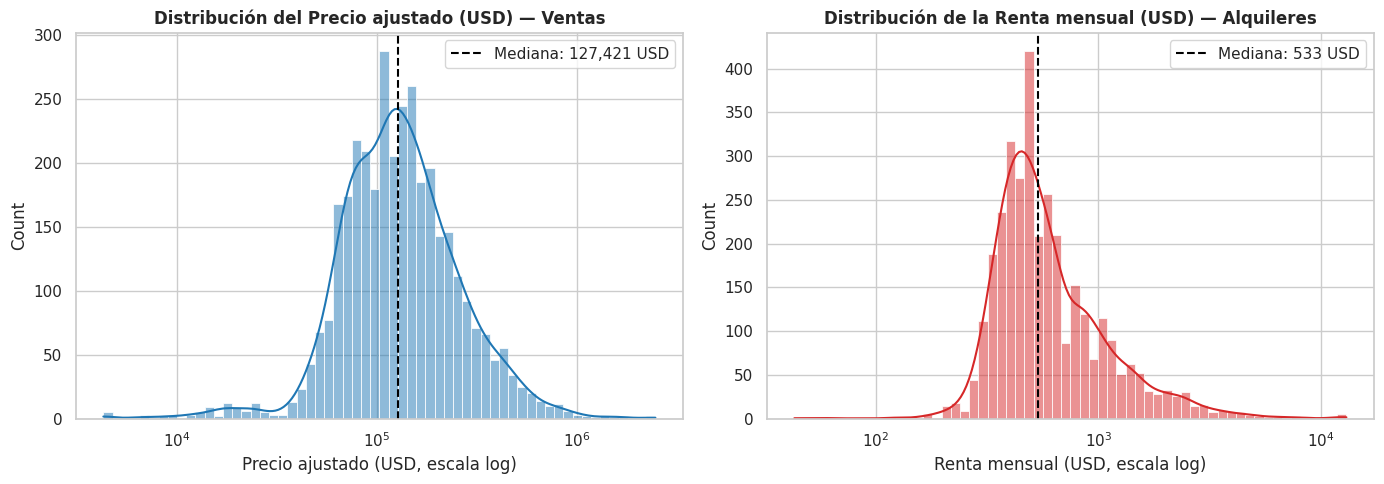

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precio ajustado USD (ventas)
sns.histplot(df_v['Precio_ajustado_USD'].dropna(), bins=60,
             color=COLOR_VENTAS, ax=axes[0], log_scale=True, kde=True)
axes[0].set_title('Distribución del Precio ajustado (USD) — Ventas')
axes[0].set_xlabel('Precio ajustado (USD, escala log)')
axes[0].axvline(df_v['Precio_ajustado_USD'].median(), color='black',
                linestyle='--', label=f"Mediana: {df_v['Precio_ajustado_USD'].median():,.0f} USD")
axes[0].legend()

# Renta mensual USD (alquileres)
sns.histplot(df_a['Renta_largo_mensual_USD'].dropna(), bins=60,
             color=COLOR_ALQ, ax=axes[1], log_scale=True, kde=True)
axes[1].set_title('Distribución de la Renta mensual (USD) — Alquileres')
axes[1].set_xlabel('Renta mensual (USD, escala log)')
axes[1].axvline(df_a['Renta_largo_mensual_USD'].median(), color='black',
                linestyle='--', label=f"Mediana: {df_a['Renta_largo_mensual_USD'].median():,.0f} USD")
axes[1].legend()

plt.tight_layout()
plt.show()

Ambas distribuciones son aproximadamente *log-normales*. El uso de escala logarítmica revela que la "curva en forma de campana" aparece después de transformar. Este resultado es ideal para el modelo predictivo.

### 5.2 Precio por m² — variable normalizada

`Precio_m2_USD` neutraliza el efecto del tamaño y da el **proxy más limpio del valor por zona**. Comparamos su distribución global y un boxplot por tipología.

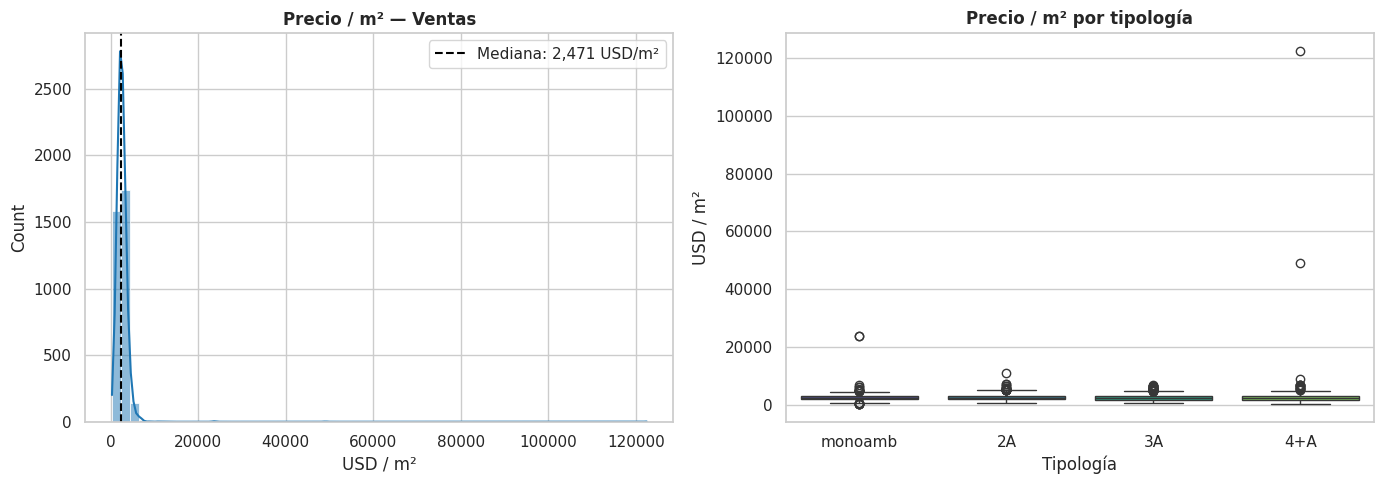

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_v['Precio_m2_USD'].dropna(), bins=60, ax=axes[0],
             color=COLOR_VENTAS, kde=True)
axes[0].set_title('Precio / m² — Ventas')
axes[0].set_xlabel('USD / m²')
axes[0].axvline(df_v['Precio_m2_USD'].median(), color='black', linestyle='--',
                label=f"Mediana: {df_v['Precio_m2_USD'].median():,.0f} USD/m²")
axes[0].legend()

sns.boxplot(data=df_v, x='Tipologia', y='Precio_m2_USD',
            order=['monoamb','2A','3A','4+A'],
            palette='viridis', ax=axes[1])
axes[1].set_title('Precio / m² por tipología')
axes[1].set_ylabel('USD / m²')
axes[1].set_xlabel('Tipología')

plt.tight_layout()
plt.show()

### 5.3 Violines superpuestos: ventas vs alquileres en Precio/m² y Renta/m²

El violín muestra a la vez la densidad y los cuantiles. Lo usamos para comparar **renta/m²** vs **precio/m²** ya normalizado (en escala log para apreciar la forma).

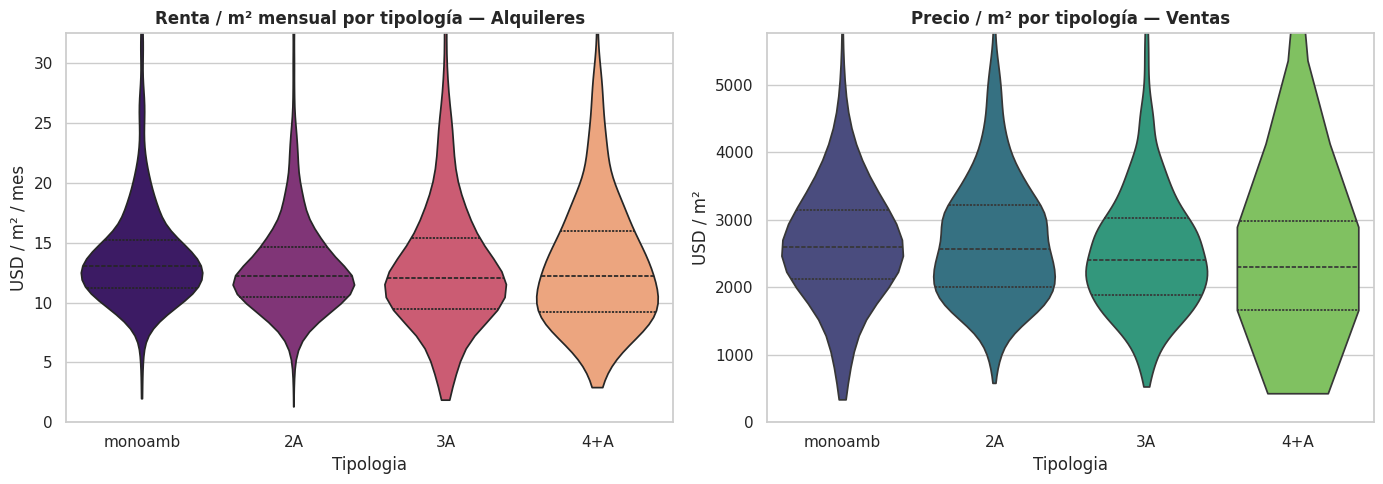

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Renta/m² por tipología (alquileres)
sns.violinplot(data=df_a, x='Tipologia', y='Renta_m2_USD',
               order=['monoamb','2A','3A','4+A'],
               palette='magma', ax=axes[0], inner='quartile', cut=0)
axes[0].set_title('Renta / m² mensual por tipología — Alquileres')
axes[0].set_ylabel('USD / m² / mes')
axes[0].set_ylim(0, df_a['Renta_m2_USD'].quantile(0.99))

# Precio/m² por tipología (ventas)
sns.violinplot(data=df_v, x='Tipologia', y='Precio_m2_USD',
               order=['monoamb','2A','3A','4+A'],
               palette='viridis', ax=axes[1], inner='quartile', cut=0)
axes[1].set_title('Precio / m² por tipología — Ventas')
axes[1].set_ylabel('USD / m²')
axes[1].set_ylim(0, df_v['Precio_m2_USD'].quantile(0.99))

plt.tight_layout()
plt.show()

Si los monoambientes muestran **mayor renta/m²** y al mismo tiempo **menor o similar precio/m²** comparados con 3A/4+A, entonces el ratio renta/precio (rentabilidad bruta) será estructuralmente más alto en los pequeños esta es la primera evidencia visual a favor de H2.

### 5.4 Superficie cubierta y antigüedad

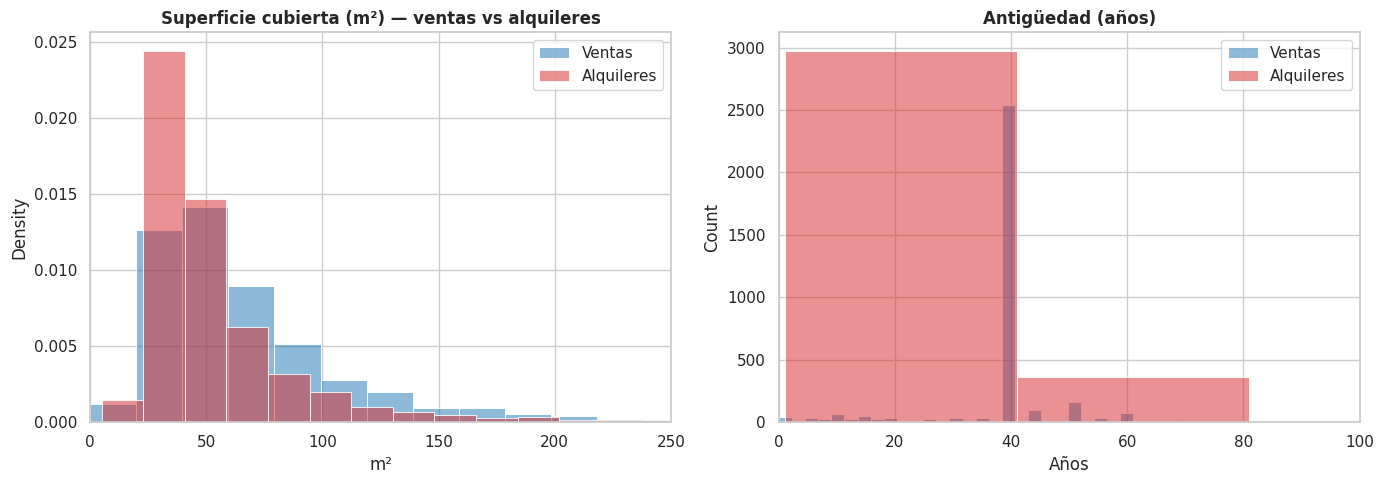

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma comparado: ventas vs alquileres en superficie
sns.histplot(df_v['Sup_Cubierta_m2'].dropna(), bins=50, color=COLOR_VENTAS,
             alpha=0.5, label='Ventas',     ax=axes[0], stat='density')
sns.histplot(df_a['Sup_Cubierta_m2'].dropna(), bins=50, color=COLOR_ALQ,
             alpha=0.5, label='Alquileres', ax=axes[0], stat='density')
axes[0].set_xlim(0, 250)
axes[0].set_title('Superficie cubierta (m²) — ventas vs alquileres')
axes[0].set_xlabel('m²')
axes[0].legend()

# Antigüedad
sns.histplot(df_v['Antiguedad'].dropna(), bins=50, color=COLOR_VENTAS,
             alpha=0.5, label='Ventas',     ax=axes[1])
sns.histplot(df_a['Antiguedad'].dropna(), bins=50, color=COLOR_ALQ,
             alpha=0.5, label='Alquileres', ax=axes[1])
axes[1].set_xlim(0, 100)
axes[1].set_title('Antigüedad (años)')
axes[1].set_xlabel('Años')
axes[1].legend()

plt.tight_layout()
plt.show()

Verificar si la distribución de superficies y antigüedades en ventas y alquileres es comparable es importante para la validez de la **tabla puente**, que asigna renta esperada a cada venta usando alquileres comparables.

## 6. Análisis bivariado y correlaciones

### 6.1 Matriz de correlación - Ventas

Construimos un heatmap de correlaciones de Spearman (más robusto a outliers que Pearson en datos asimétricos como estos) para identificar relaciones lineales/monótonas entre las variables clave del dataset de ventas.

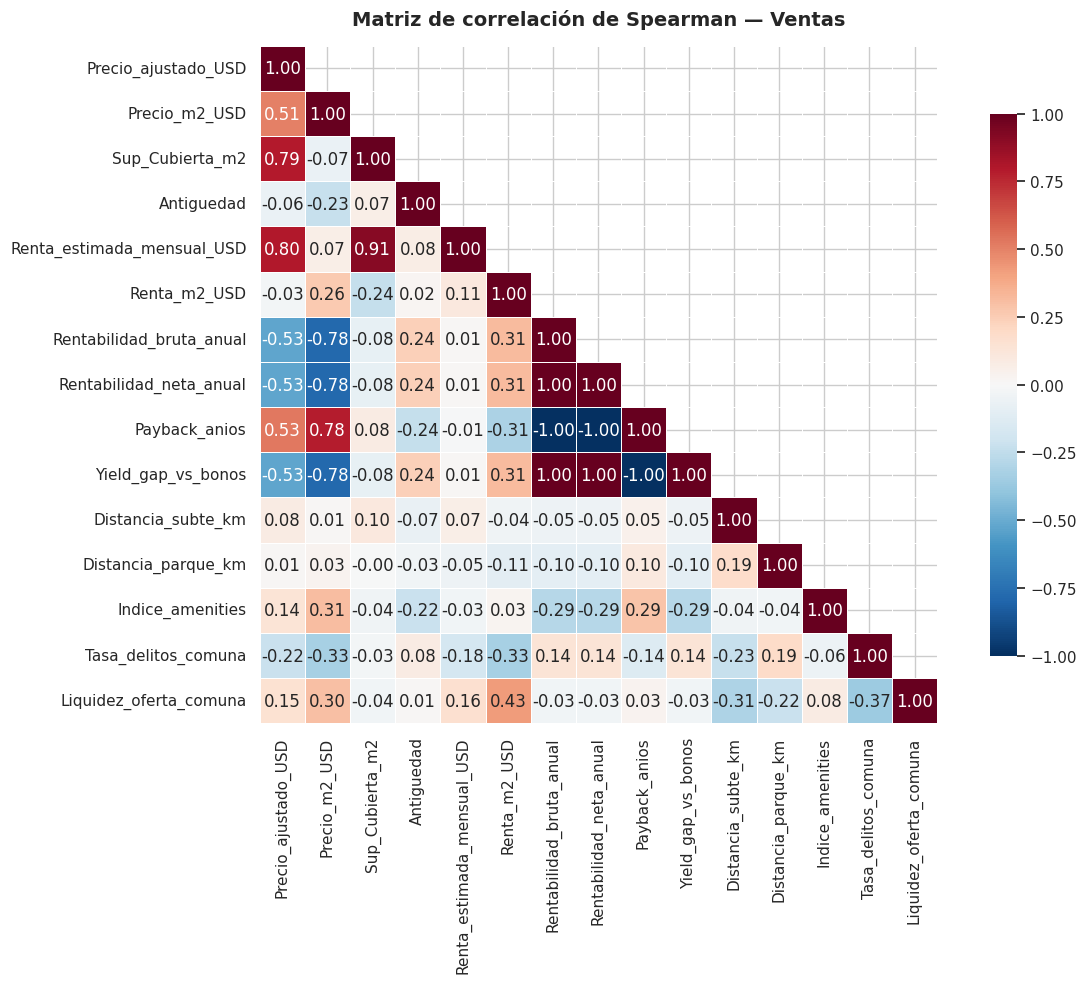

In [ ]:
cols_corr = ['Precio_ajustado_USD','Precio_m2_USD','Sup_Cubierta_m2','Antiguedad',
             'Renta_estimada_mensual_USD','Renta_m2_USD','Rentabilidad_bruta_anual',
             'Rentabilidad_neta_anual','Payback_anios','Yield_gap_vs_bonos',
             'Distancia_subte_km','Distancia_parque_km','Indice_amenities',
             'Tasa_delitos_comuna','Liquidez_oferta_comuna']
cols_corr = [c for c in cols_corr if c in df_v.columns]

corr = df_v[cols_corr].corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Matriz de correlación de Spearman — Ventas', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

**Qué indica el heatmap:**

- `Precio_m2_US`D vs `Distancia_subte_km` (rho = 0.01): correlación prácticamente nula. La cercanía al subte no está capitalizada en el precio/m², contrario a lo esperado por H1. Se profundizará en el archivo de hipótesis.
- `Rentabilidad_bruta_anual` vs `Distancia_subte_km` (rho = -0.05): correlación negativa débil. Las propiedades más lejanas al subte no parece mayor rentabilidad, lo que también iría en contra de H1. El subte no generaría yield diferencial en ninguna variable.
- `Precio_m2_USD` vs `Distancia_parque_km` (rho = 0.03): correlación positiva mínima. No se observa el efecto esperado por H3 — la cercanía a parques no se asocia con mayor precio/m².
- `Rentabilidad_bruta_anual` vs `Sup_Cubierta_m2` (rho = -0.08): correlación negativa débil pero consistente. A mayor superficie, menor rentabilidad bruta, lo que es un primer indicio favorable a H2. Indaga H2.
- `Tasa_delitos_comuna` vs `Rentabilidad_bruta_anual` (rho = 0.14): correlación positiva moderada. Las zonas de mayor delito muestran mayor rentabilidad bruta, lo que sugiere que el mercado descuenta el riesgo vía precio más bajo. Indaga H5.
- `Precio_m2_USD` vs `Indice_amenities` (rho = 0.31): la correlación más fuerte de la tabla junto a liquidez. Mayor índice de amenities se asocia claramente con mayor precio/m².
- `Liquidez_oferta_comuna` vs `Precio_m2_USD` (rho = 0.30): las comunas con más publicaciones por habitante concentran también los precios más altos, reflejando que demanda y oferta coexisten en las zonas premium.

### 6.2 Matriz de correlación — Alquileres

Hacemos lo mismo para los alquileres, con foco en cómo la renta mensual y por m² se relaciona con superficie, antigüedad y entorno urbano.

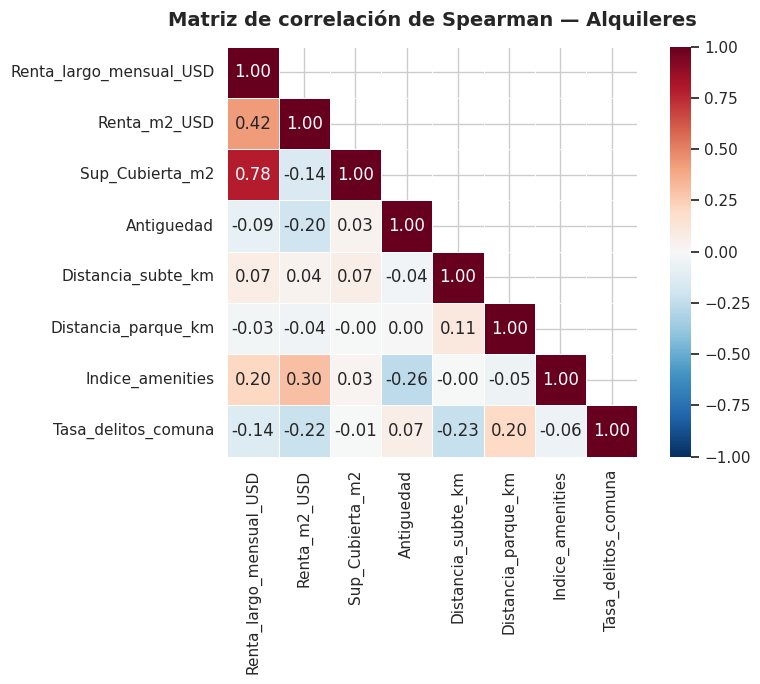

In [ ]:
cols_corr_a = ['Renta_largo_mensual_USD','Renta_m2_USD','Sup_Cubierta_m2','Antiguedad',
               'Distancia_subte_km','Distancia_parque_km','Indice_amenities','Tasa_delitos_comuna']
cols_corr_a = [c for c in cols_corr_a if c in df_a.columns]

corr_a = df_a[cols_corr_a].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_a, dtype=bool), k=1)
sns.heatmap(corr_a, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlación de Spearman — Alquileres', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

**Indica:**

- `Renta_largo_mensual_USD` vs `Sup_Cubierta_m2` (rho = 0.78): la correlación más fuerte de la matriz. La renta mensual está dominada por el tamaño del departamento — propiedades más grandes alquilan por más en términos absolutos.
- `Renta_m2_USD` vs `Sup_Cubierta_m2` (rho = -0.14): correlación negativa débil. A mayor superficie, menor renta por m², consistente con lo observado en ventas y favorable a H2: los departamentos pequeños generan más renta por unidad de superficie.
- `Renta_m2_USD` vs `Indice_amenities` (rho = 0.30): los departamentos con más amenities alcanzan mayor renta por m², efecto similar al observado en precio de ventas. Los amenities generan valor tanto en compra como en alquiler.
- `Renta_m2_USD` vs `Antiguedad` (rho = -0.20): los departamentos más nuevos tienen mayor renta por m². Indicio favorable a H4 desde el lado del alquiler: la condición del inmueble se refleja en la renta, aunque el efecto es moderado.
- `Renta_largo_mensual_USD` vs `Tasa_delitos_comuna` (rho = -0.14) y `Renta_m2_USD` vs `Tasa_delitos_comuna` (rho = -0.22): en zonas de mayor delito la renta es menor, tanto en términos absolutos como por m². Complementa lo observado en ventas para H5: el mercado castiga el riesgo vía precio de compra más bajo (mayor rentabilidad en ventas) pero también vía renta más baja (menor ingreso en alquileres).
- `Distancia_subte_km` vs `Renta_m2_USD` (rho = 0.04): correlación prácticamente nula, consistente con ventas. La cercanía al subte no genera diferencial de renta por m², reforzando la lectura de H1.
- `Distancia_parque_km` vs `Renta_m2_USD` (rho = -0.04): también nula, consistente con la no confirmación de H3 en ventas.

### 6.3 Scatter plots

Vamos a inspeccionar visualmente los pares que aparecieron interesantes en la matriz.

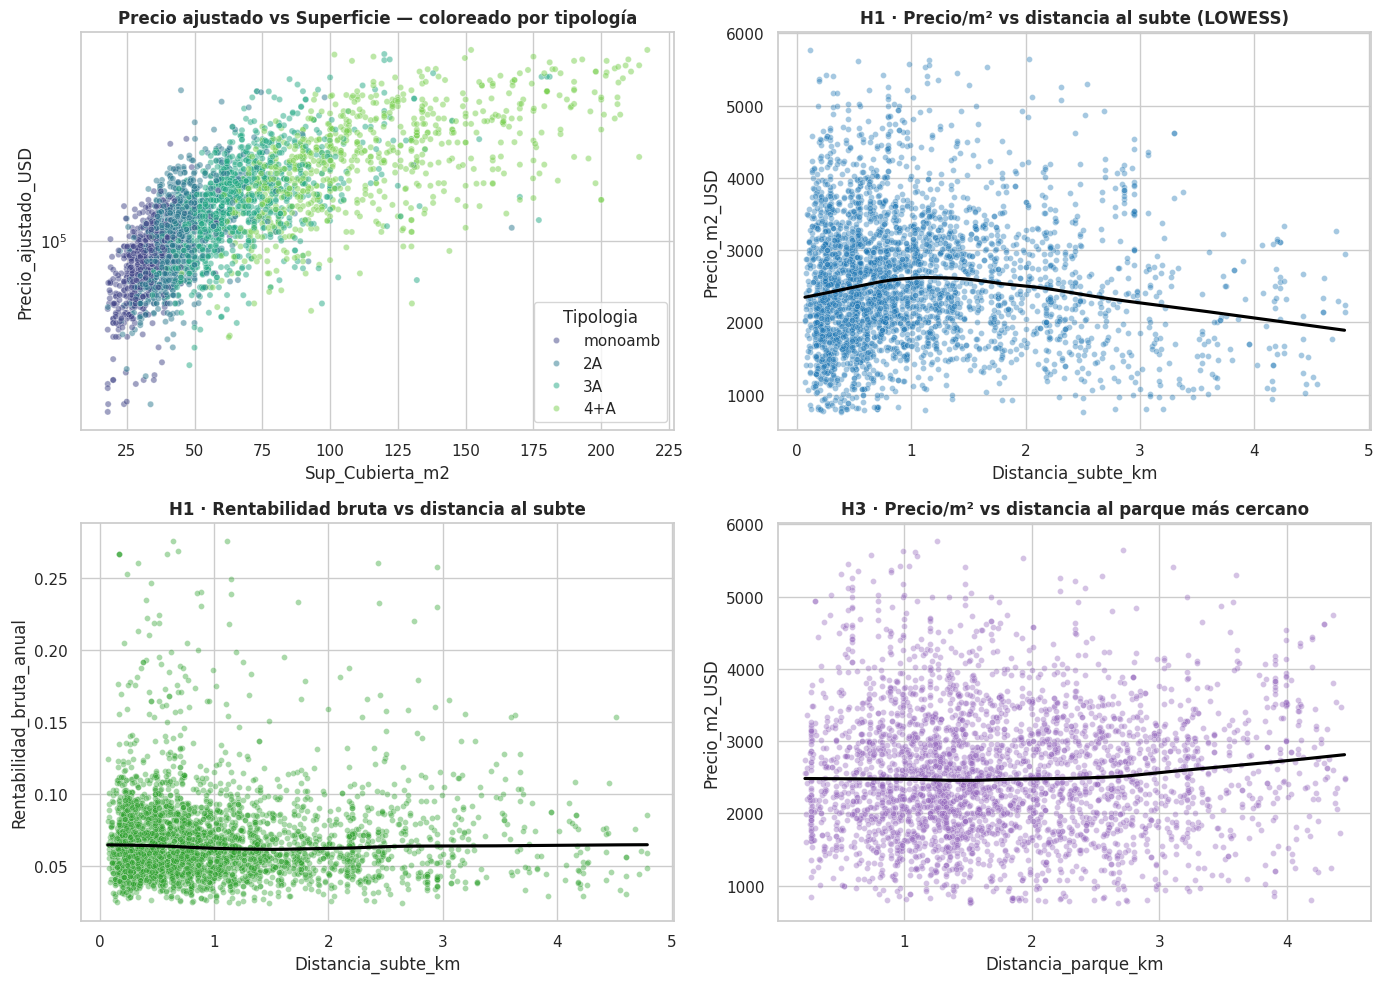

In [ ]:
# Pre-filtrado de outliers extremos para que los scatters se lean (p1-p99)
def trim(df, col, lo=0.01, hi=0.99):
    a, b = df[col].quantile(lo), df[col].quantile(hi)
    return df[(df[col] >= a) & (df[col] <= b)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Precio_USD vs Sup_Cubierta
d = trim(trim(df_v, 'Precio_ajustado_USD'), 'Sup_Cubierta_m2')
sns.scatterplot(data=d, x='Sup_Cubierta_m2', y='Precio_ajustado_USD',
                hue='Tipologia', hue_order=['monoamb','2A','3A','4+A'],
                palette='viridis', alpha=0.5, s=20, ax=axes[0,0])
axes[0,0].set_title('Precio ajustado vs Superficie — coloreado por tipología')
axes[0,0].set_yscale('log')

# (2) Precio_m2_USD vs Distancia_subte_km   (H1)
d = trim(trim(df_v, 'Precio_m2_USD'), 'Distancia_subte_km')
sns.scatterplot(data=d, x='Distancia_subte_km', y='Precio_m2_USD',
                color=COLOR_VENTAS, alpha=0.4, s=18, ax=axes[0,1])
sns.regplot(data=d, x='Distancia_subte_km', y='Precio_m2_USD',
            scatter=False, color='black', lowess=True, ax=axes[0,1])
axes[0,1].set_title('H1 · Precio/m² vs distancia al subte (LOWESS)')

# (3) Rentabilidad_bruta vs Distancia_subte (núcleo de H1)
d = trim(trim(df_v, 'Rentabilidad_bruta_anual'), 'Distancia_subte_km')
sns.scatterplot(data=d, x='Distancia_subte_km', y='Rentabilidad_bruta_anual',
                color='#2ca02c', alpha=0.4, s=18, ax=axes[1,0])
sns.regplot(data=d, x='Distancia_subte_km', y='Rentabilidad_bruta_anual',
            scatter=False, color='black', lowess=True, ax=axes[1,0])
axes[1,0].set_title('H1 · Rentabilidad bruta vs distancia al subte')

# (4) Precio_m2 vs Distancia_parque  (H3)
d = trim(trim(df_v, 'Precio_m2_USD'), 'Distancia_parque_km')
sns.scatterplot(data=d, x='Distancia_parque_km', y='Precio_m2_USD',
                color='#9467bd', alpha=0.4, s=18, ax=axes[1,1])
sns.regplot(data=d, x='Distancia_parque_km', y='Precio_m2_USD',
            scatter=False, color='black', lowess=True, ax=axes[1,1])
axes[1,1].set_title('H3 · Precio/m² vs distancia al parque más cercano')

plt.tight_layout()
plt.show()

- *(1)* La relación **Precio–Superficie** es positiva pero no lineal en niveles (sí lo es en log). Los colores por tipología muestran que dentro de cada categoría la dispersión se reduce — la tipología captura mucho del precio.
- *(2)* Como la curva LOWESS de **Precio/m² vs distancia al subte** cae con la distancia, existe una capitalización del subte en el precio.
- *(3)* La pieza crítica: si el LOWESS de **rentabilidad bruta vs distancia al subte** es **plano**, H1 queda apoyada — el subte se paga en precio pero la renta lo sigue.
- *(4)* Distancia al parque vs precio/m²: muestra una curva LOWESS con pendiente levemente positiva,. Eso significa que a mayor distancia al parque, el precio/m² tiende a subir levemente — lo opuesto a lo esperado por H3.

### 6.4 Antigüedad y amenities

Dos variables más que esperamos correlacionadas con precio, y que conectan con H4 (`A_estrenar` = `Antiguedad == 0`).

**Advertencia sobre la variable Antigüedad**: Más del 60% de los valores fueron imputados con la mediana por tipo de unidad durante la etapa de limpieza. Esto produce una concentración artificial alrededor de los 40 años en ambos datasets que no refleja la distribución real del mercado. Por este motivo, Antigüedad debe usarse con cautela en análisis cuantitativos — ***su variabilidad está artificialmente reducida***. La única excepción es el subgrupo A_estrenar (antigüedad = 0), que proviene de datos reales no imputados y puede usarse con mayor confianza para la validación de H4.

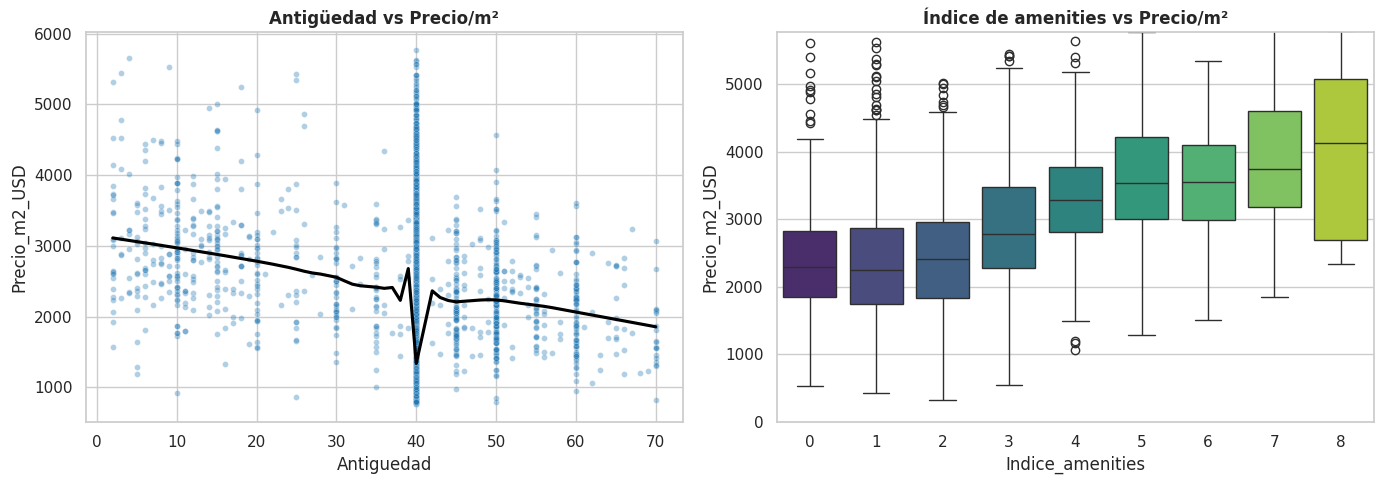

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antigüedad vs Precio/m²
d = trim(trim(df_v, 'Precio_m2_USD'), 'Antiguedad')
sns.scatterplot(data=d, x='Antiguedad', y='Precio_m2_USD',
                color=COLOR_VENTAS, alpha=0.35, s=18, ax=axes[0])
sns.regplot(data=d, x='Antiguedad', y='Precio_m2_USD',
            scatter=False, color='black', lowess=True, ax=axes[0])
axes[0].set_title('Antigüedad vs Precio/m²')

# Indice_amenities vs Precio_m2 (boxplot)
sns.boxplot(data=df_v, x='Indice_amenities', y='Precio_m2_USD',
            palette='viridis', ax=axes[1])
axes[1].set_ylim(0, df_v['Precio_m2_USD'].quantile(0.99))
axes[1].set_title('Índice de amenities vs Precio/m²')

plt.tight_layout()
plt.show()

**Índice de amenities** vs **Precio/m²**: La relación es monotónicamente creciente y visualmente robusta. Cada amenity adicional se asocia con un escalón de **precio/m²** más alto, con medianas que van de ~USD 2.200/m² (sin amenities) a ~USD 4.000/m² (8 amenities). La dispersión también crece con el índice, lo que sugiere que los amenities operan en segmentos premium donde la varianza de precio es mayor. Este resultado es consistente con el rho = 0.31 de la matriz de correlación y anticipa que **Indice_amenities** será una variable relevante en el análisis de precio.

## 7. Dispersión espacial — el mapa de CABA

1. **Precio/m² por propiedad** (mancha de valor en la ciudad).
2. **Rentabilidad bruta por propiedad** (mancha de retorno).
3. **Renta/m² por propiedad** (alquileres).

In [ ]:
# Filtramos al p99 para que la escala de color no se rompa con outliers
def to_p99(df, col):
    return df[df[col] <= df[col].quantile(0.99)]

CENTER_CABA = {'lat': -34.610, 'lon': -58.420}

fig = px.scatter_mapbox(
    to_p99(df_v.dropna(subset=['Precio_m2_USD','lat','lon']), 'Precio_m2_USD'),
    lat='lat', lon='lon',
    color='Precio_m2_USD',
    color_continuous_scale='Viridis',
    size_max=8, opacity=0.6, zoom=11,
    center=CENTER_CABA,
    mapbox_style='carto-positron',
    hover_data={'Barrio': True, 'Tipologia': True, 'Sup_Cubierta_m2': True,
                'Precio_USD': ':,.0f', 'Precio_m2_USD': ':,.0f', 'lat': False, 'lon': False},
    title='Dispersión espacial · Precio/m² (USD) — Ventas'
)
fig.update_layout(height=600, margin=dict(l=0, r=0, t=40, b=0))
fig.show()

**Dispersión espacial · Precio/m² (USD) — Ventas:** Los precios más altos (amarillo/verde claro) se concentran en la franja noreste de CABA — Palermo, Recoleta, Belgrano, Puerto Madero — con una degradación clara hacia el sur y el oeste.

In [ ]:
# Rentabilidad bruta — visualización del retorno por ubicación
d = df_v.dropna(subset=['Rentabilidad_bruta_anual','lat','lon'])
d = d[d['Rentabilidad_bruta_anual'].between(d['Rentabilidad_bruta_anual'].quantile(0.01),
                                            d['Rentabilidad_bruta_anual'].quantile(0.99))]

fig = px.scatter_mapbox(
    d, lat='lat', lon='lon',
    color='Rentabilidad_bruta_anual',
    color_continuous_scale='RdYlGn',
    range_color=(d['Rentabilidad_bruta_anual'].quantile(0.05),
                 d['Rentabilidad_bruta_anual'].quantile(0.95)),
    size_max=8, opacity=0.6, zoom=11,
    center=CENTER_CABA,
    mapbox_style='carto-positron',
    hover_data={'Barrio': True, 'Tipologia': True, 'Zona_riesgo': True,
                'Rentabilidad_bruta_anual': ':.3f', 'lat': False, 'lon': False},
    title='Dispersión espacial · Rentabilidad bruta anual — Ventas'
)
fig.update_layout(height=600, margin=dict(l=0, r=0, t=40, b=0))
fig.show()

**Dispersión espacial · Rentabilidad bruta anual — Ventas:** El patrón espacial de rentabilidad es prácticamente inverso al de precio/m². Las zonas de mayor rentabilidad (rojo/naranja) aparecen en el sur y oeste de CABA — comunas 4, 8, 9, 10 — mientras que las zonas premium del norte muestran rentabilidades bajas (verde). Esto es consistente con el mecanismo de H5: el mercado descuenta el riesgo vía precio más bajo, generando mayor ratio renta/precio en zonas de menor demanda. Para el fondo, este mapa es el más accionable: identifica visualmente dónde existe oportunidad de yield superior, que deberá cruzarse con zona de riesgo y liquidez antes de tomar decisiones.

In [ ]:
# Renta/m² para los alquileres
d = df_a.dropna(subset=['Renta_m2_USD','lat','lon'])
d = to_p99(d, 'Renta_m2_USD')

fig = px.scatter_mapbox(
    d, lat='lat', lon='lon',
    color='Renta_m2_USD',
    color_continuous_scale='Plasma',
    size_max=7, opacity=0.55, zoom=11,
    center=CENTER_CABA,
    mapbox_style='carto-positron',
    hover_data={'Barrio': True, 'Tipologia': True, 'Sup_Cubierta_m2': True,
                'Renta_largo_mensual_USD': ':,.0f', 'Renta_m2_USD': ':.2f',
                'lat': False, 'lon': False},
    title='Dispersión espacial · Renta/m² (USD/mes) — Alquileres'
)
fig.update_layout(height=600, margin=dict(l=0, r=0, t=40, b=0))
fig.show()




**Dispersión espacial · Renta/m² (USD/mes) — Alquileres:** La renta por m² más alta (amarillo/blanco) se concentra también en el noreste, con valores que contrastan con el sur y oeste. Sin embargo, la dispersión es mayor que en el mapa de precio de ventas — hay puntos de alta renta/m² dispersos en zonas de precio medio, lo que sugiere oportunidades de arbitraje donde el precio de compra no refleja completamente la capacidad de renta del inmueble.

## 8. Lecturas por comuna y tipología

Agregamos por comuna para producir el panel que mira el fondo: dónde están las medianas, dónde hay liquidez y dónde hay yield.

In [ ]:
# Panel por comuna — ventas
agg_v = (df_v.dropna(subset=['Comuna'])
            .groupby('Comuna')
            .agg(n_ventas=('Precio_USD','count'),
                 precio_m2_mediano=('Precio_m2_USD','median'),
                 rent_bruta_mediana=('Rentabilidad_bruta_anual','median'),
                 rent_neta_mediana=('Rentabilidad_neta_anual','median'),
                 payback_mediano=('Payback_anios','median'),
                 yield_gap_mediano=('Yield_gap_vs_bonos','median'),
                 liquidez=('Liquidez_oferta_comuna','first'),
                 tasa_delitos=('Tasa_delitos_comuna','first'))
            .reset_index())
agg_v['Comuna'] = agg_v['Comuna'].astype(int)
agg_v.sort_values('precio_m2_mediano', ascending=False).round(3)

,Comuna,n_ventas,precio_m2_mediano,rent_bruta_mediana,rent_neta_mediana,payback_mediano,yield_gap_mediano,liquidez,tasa_delitos
13,14,449,"3,076.923",0.059,0.023,16.954,-0.041,0.002,0.317
12,13,419,"3,050.000",0.057,0.021,17.489,-0.043,0.002,0.324
11,12,332,"2,950.000",0.054,0.018,18.615,-0.046,0.002,0.500
1,2,227,"2,763.158",0.059,0.023,16.859,-0.041,0.001,1.045
10,11,203,"2,493.750",0.057,0.021,17.585,-0.043,0.001,0.579
14,15,309,"2,405.498",0.063,0.027,15.848,-0.037,0.002,0.356
5,6,259,"2,342.857",0.068,0.031,14.758,-0.032,0.001,0.682
4,5,234,"2,285.358",0.060,0.024,16.550,-0.040,0.001,0.726
9,10,132,"2,021.220",0.064,0.028,15.631,-0.036,0.001,0.482
6,7,163,"1,926.667",0.069,0.033,14.405,-0.031,0.001,0.431


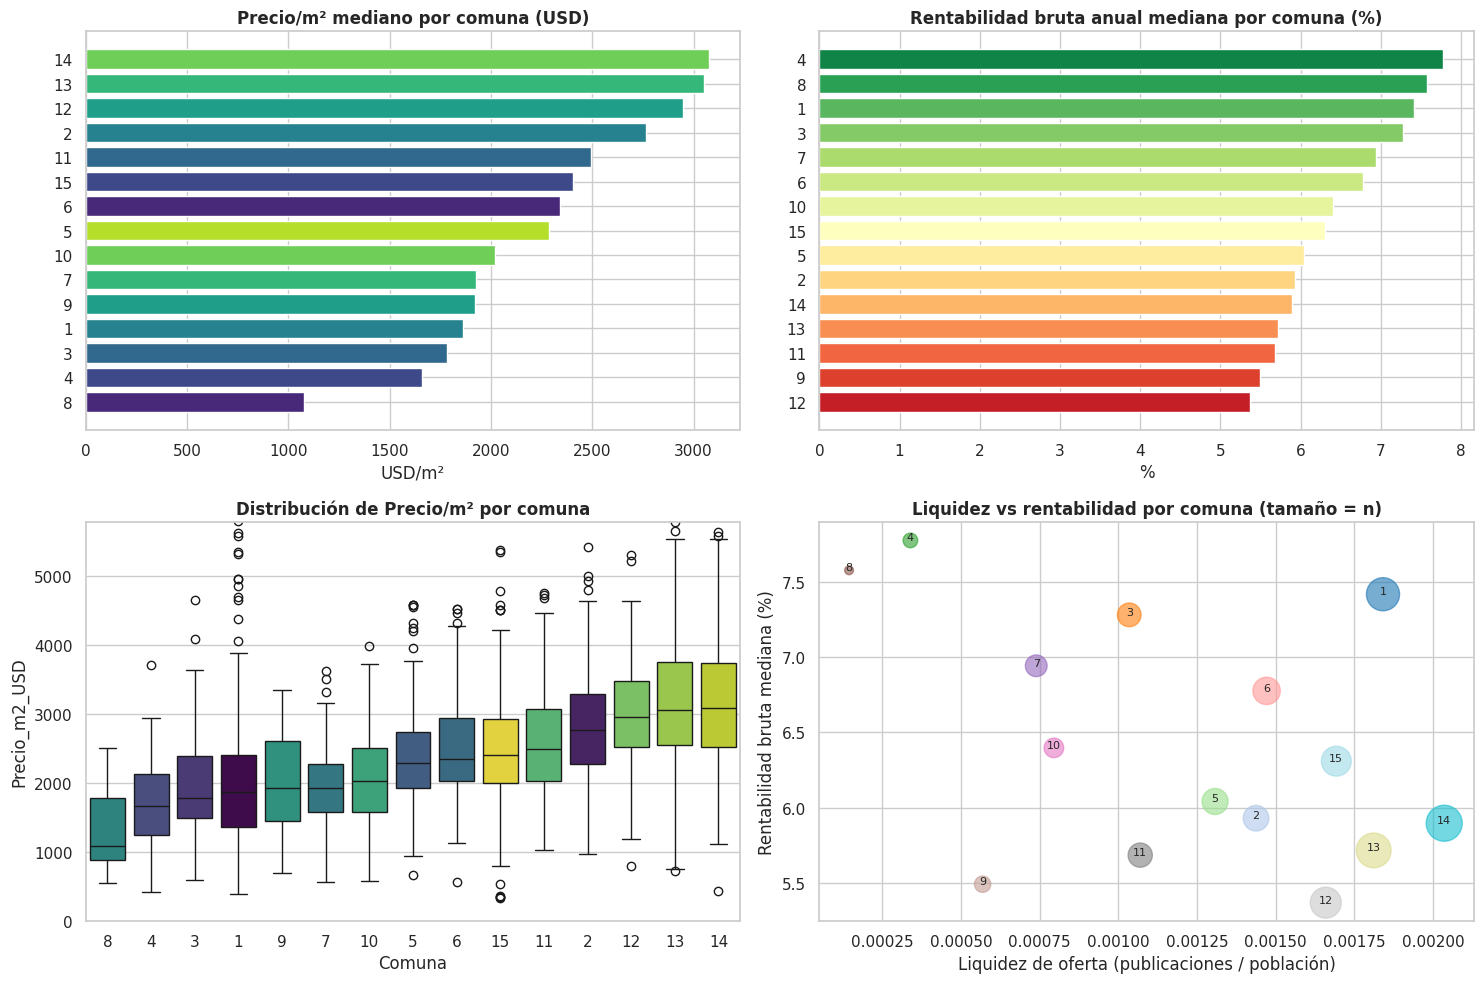

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (1) Precio/m² mediano por comuna
d1 = agg_v.sort_values('precio_m2_mediano', ascending=True)
axes[0,0].barh(d1['Comuna'].astype(str), d1['precio_m2_mediano'], color=PALETA)
axes[0,0].set_title('Precio/m² mediano por comuna (USD)')
axes[0,0].set_xlabel('USD/m²')

# (2) Rentabilidad bruta mediana por comuna
d2 = agg_v.sort_values('rent_bruta_mediana', ascending=True)
axes[0,1].barh(d2['Comuna'].astype(str), d2['rent_bruta_mediana']*100,
               color=sns.color_palette('RdYlGn', len(d2)))
axes[0,1].set_title('Rentabilidad bruta anual mediana por comuna (%)')
axes[0,1].set_xlabel('%')

# (3) Boxplot precio_m2 por comuna
d_box = df_v.dropna(subset=['Comuna']).copy()
d_box['Comuna'] = d_box['Comuna'].astype(int)
order = agg_v.sort_values('precio_m2_mediano')['Comuna'].astype(int).tolist()
sns.boxplot(data=d_box, x='Comuna', y='Precio_m2_USD',
            hue='Comuna', order=order, palette='viridis',
            legend=False, ax=axes[1,0])
axes[1,0].set_title('Distribución de Precio/m² por comuna')
axes[1,0].set_ylim(0, df_v['Precio_m2_USD'].quantile(0.99))

# (4) Liquidez vs rentabilidad bruta
axes[1,1].scatter(agg_v['liquidez'], agg_v['rent_bruta_mediana']*100,
                  s=agg_v['n_ventas']*1.5, alpha=0.6, c=agg_v['Comuna'], cmap='tab20')
for _, r in agg_v.iterrows():
    axes[1,1].annotate(int(r['Comuna']),
                       (r['liquidez'], r['rent_bruta_mediana']*100),
                       fontsize=8, ha='center')
axes[1,1].set_xlabel('Liquidez de oferta (publicaciones / población)')
axes[1,1].set_ylabel('Rentabilidad bruta mediana (%)')
axes[1,1].set_title('Liquidez vs rentabilidad por comuna (tamaño = n)')

plt.tight_layout()
plt.show()

**Precio/m² mediano por comuna:** La comuna 14 (Palermo) encabeza el ranking con aprox. USD 3.000/m², seguida por 13 (Belgrano) y 12 (Coghlan/Saavedra). En el extremo opuesto, la comuna 8 (Villa Soldati/Lugano) muestra el precio más bajo (aprox. USD 1.000/m²), con una brecha de 3x respecto al máximo. Este ordenamiento es el mapa de referencia de valor para el fondo.

**Rentabilidad bruta anual mediana por comuna**: El ranking se invierte casi completamente respecto al precio. La comuna 4 (La Boca/Barracas) lidera con alrededor de 7,5%, seguida por comunas 1 y 3. Las comunas premium 14, 13 y 12 aparecen en la mitad inferior del ranking con rentabilidades de ~6%. La comuna 12 es la de menor rentabilidad bruta (aprox. 5,5%). Este patrón confirma el mecanismo precio-renta: donde el precio es alto, pero la renta no crece proporcionalmente.

**Distribución de Precio/m² por comuna:** Los boxplots revelan que la dispersión interna crece con el precio mediano. Las comunas premium (14, 13, 12) tienen mayor varianza y más outliers hacia arriba, lo que se traduce en mayor `Volatilidad_Precio_m2_comuna` y mayor riesgo de valuación. Las comunas del sur muestran distribuciones más compactas, es decir, mercados más homogéneos y predecibles.

**Liquidez vs Rentabilidad por comuna:** Este es un gráfico clave para el fondo. El cuadrante superior derecho (alta rentabilidad y alta liquidez) es la zona de inversión óptima. Las comunas 1, 3 y 4 combinan rentabilidad superior al 6,5% con liquidez media-alta. La comuna 8, pese a tener rentabilidad atractiva (~7%), aparece con liquidez muy baja (solo 27 publicaciones) y tamaño de burbuja pequeño, descartándola como mercado escalable. Las comunas 14 y 13 tienen alta liquidez pero rentabilidad más baja, posicionándolas como mercados seguros pero no óptimos en yield.

## 9. Evidencia preliminar sobre las hipótesis

Estos gráficos no validan estadísticamente las hipótesis pero **revelan si la dirección de los datos es consistente** con cada H.

### H1 — Subte: precio sí, renta no

Comparamos la distribución de precio/m² y de rentabilidad bruta entre propiedades **cerca del subte** (≤ 500 m) y **lejos** (> 1 km).

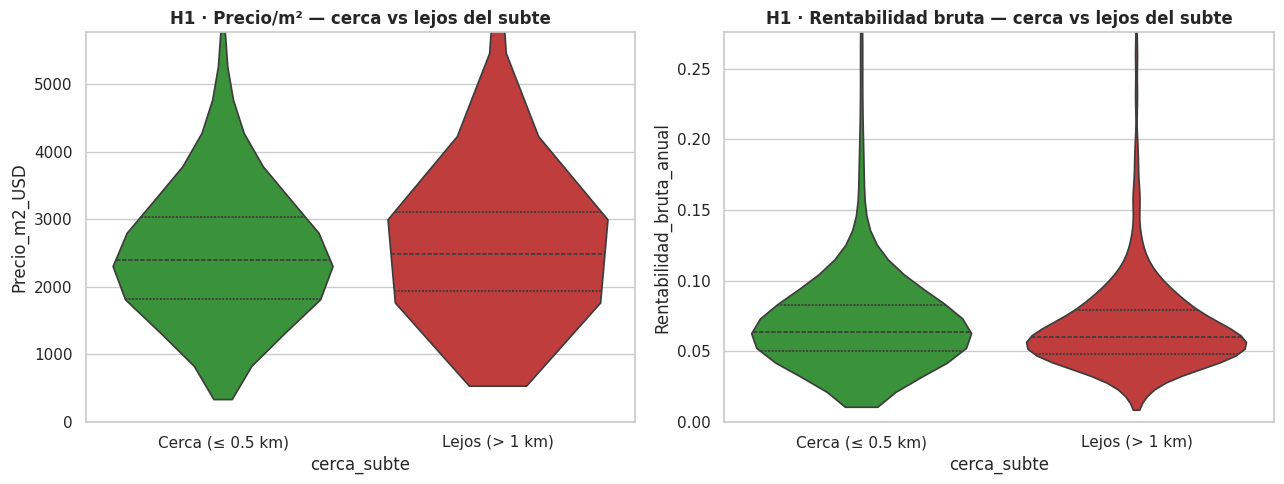

Medianas H1:
                  Precio_m2_USD  Rentabilidad_bruta_anual
cerca_subte                                              
Cerca (≤ 0.5 km)      2,392.081                     0.064
Intermedio            2,529.412                     0.063
Lejos (> 1 km)        2,485.281                     0.060


In [ ]:
df_v['cerca_subte'] = np.where(df_v['Distancia_subte_km'] <= 0.5, 'Cerca (≤ 0.5 km)',
                       np.where(df_v['Distancia_subte_km'] >  1.0, 'Lejos (> 1 km)', 'Intermedio'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.violinplot(data=df_v[df_v['cerca_subte'].isin(['Cerca (≤ 0.5 km)','Lejos (> 1 km)'])],
               x='cerca_subte', y='Precio_m2_USD',
               order=['Cerca (≤ 0.5 km)','Lejos (> 1 km)'],
               palette=['#2ca02c','#d62728'], ax=axes[0], cut=0, inner='quartile')
axes[0].set_ylim(0, df_v['Precio_m2_USD'].quantile(0.99))
axes[0].set_title('H1 · Precio/m² — cerca vs lejos del subte')

sns.violinplot(data=df_v[df_v['cerca_subte'].isin(['Cerca (≤ 0.5 km)','Lejos (> 1 km)'])],
               x='cerca_subte', y='Rentabilidad_bruta_anual',
               order=['Cerca (≤ 0.5 km)','Lejos (> 1 km)'],
               palette=['#2ca02c','#d62728'], ax=axes[1], cut=0, inner='quartile')
axes[1].set_ylim(0, df_v['Rentabilidad_bruta_anual'].quantile(0.99))
axes[1].set_title('H1 · Rentabilidad bruta — cerca vs lejos del subte')

plt.tight_layout()
plt.show()

print('Medianas H1:')
print(df_v.groupby('cerca_subte')[['Precio_m2_USD','Rentabilidad_bruta_anual']].median().round(4))

### H2 — Tipología y rentabilidad

Si los monoambientes rinden más que los 4+A, lo veremos como una **escalera descendente** en la rentabilidad bruta por tipología.

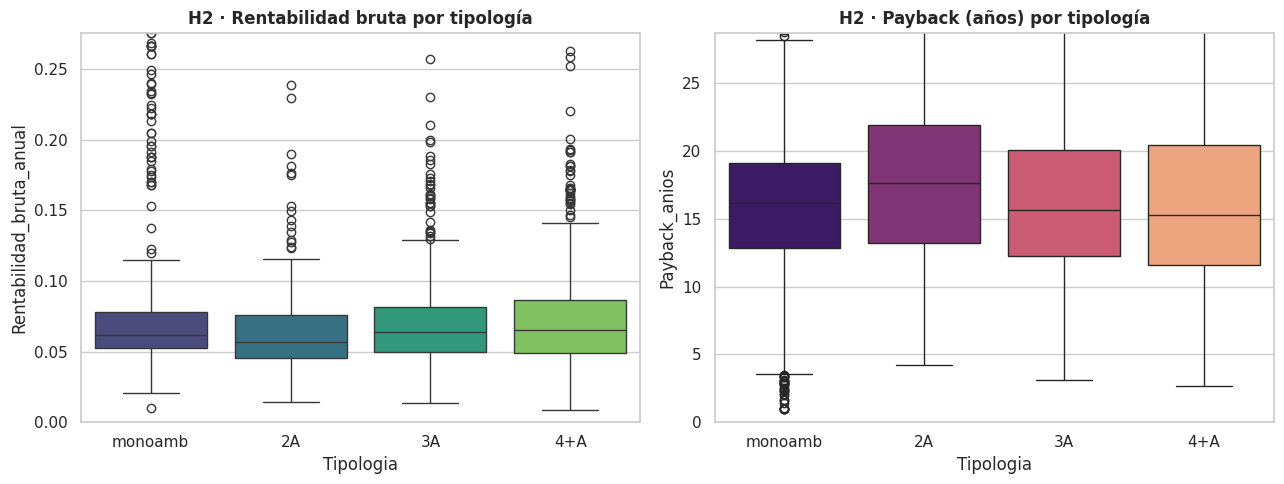

Medianas por tipología:
           Rentabilidad_bruta_anual  Payback_anios  Precio_m2_USD
Tipologia                                                        
monoamb                       0.062         16.139      2,600.000
2A                            0.057         17.662      2,564.444
3A                            0.064         15.670      2,405.289
4+A                           0.066         15.251      2,307.692


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_v, x='Tipologia', y='Rentabilidad_bruta_anual',
            order=['monoamb','2A','3A','4+A'], palette='viridis', ax=axes[0])
axes[0].set_ylim(0, df_v['Rentabilidad_bruta_anual'].quantile(0.99))
axes[0].set_title('H2 · Rentabilidad bruta por tipología')

sns.boxplot(data=df_v, x='Tipologia', y='Payback_anios',
            order=['monoamb','2A','3A','4+A'], palette='magma', ax=axes[1])
axes[1].set_ylim(0, df_v['Payback_anios'].quantile(0.95))
axes[1].set_title('H2 · Payback (años) por tipología')

plt.tight_layout()
plt.show()

print('Medianas por tipología:')
print(df_v.groupby('Tipologia')[['Rentabilidad_bruta_anual','Payback_anios','Precio_m2_USD']]
      .median().reindex(['monoamb','2A','3A','4+A']).round(4))

### H3 — Parque y precio/m²

Comparación cerca (≤ 0.5 km) vs lejos (> 1.5 km) de un parque urbano relevante.

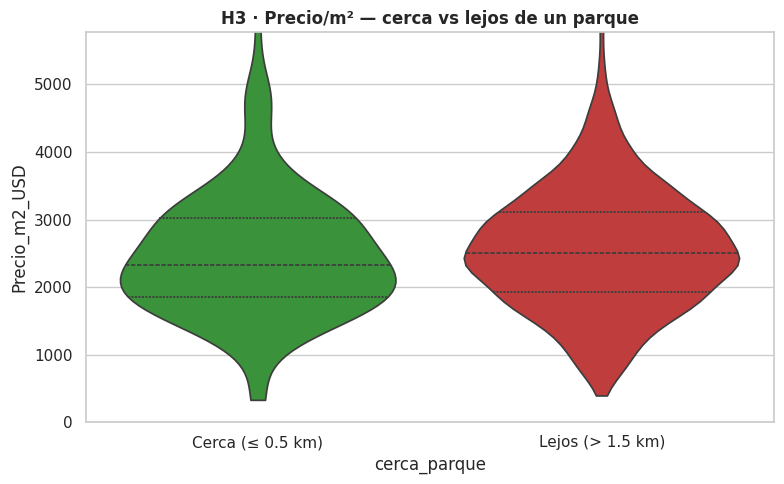

Medianas H3:
                  Precio_m2_USD
cerca_parque                   
Cerca (≤ 0.5 km)      2,328.070
Intermedio            2,435.400
Lejos (> 1.5 km)      2,500.000


In [ ]:
df_v['cerca_parque'] = np.where(df_v['Distancia_parque_km'] <= 0.5, 'Cerca (≤ 0.5 km)',
                        np.where(df_v['Distancia_parque_km'] >  1.5, 'Lejos (> 1.5 km)', 'Intermedio'))

fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df_v[df_v['cerca_parque'].isin(['Cerca (≤ 0.5 km)','Lejos (> 1.5 km)'])],
               x='cerca_parque', y='Precio_m2_USD',
               order=['Cerca (≤ 0.5 km)','Lejos (> 1.5 km)'],
               palette=['#2ca02c','#d62728'], ax=ax, cut=0, inner='quartile')
ax.set_ylim(0, df_v['Precio_m2_USD'].quantile(0.99))
ax.set_title('H3 · Precio/m² — cerca vs lejos de un parque')
plt.tight_layout()
plt.show()

print('Medianas H3:')
print(df_v.groupby('cerca_parque')[['Precio_m2_USD']].median().round(2))

### H4 — A estrenar: premium en precio, peor payback

`A_estrenar = 1` significa antigüedad cero

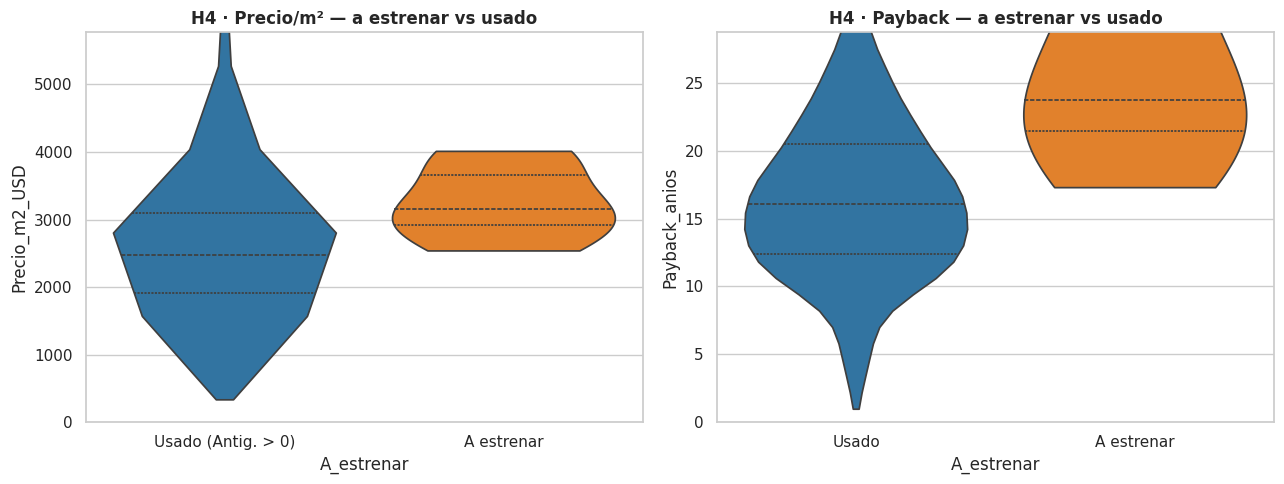

Medianas H4:
            Precio_m2_USD  Payback_anios  Rentabilidad_bruta_anual
A_estrenar                                                        
0               2,468.750         16.071                     0.062
1               3,153.061         23.713                     0.043


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.violinplot(data=df_v, x='A_estrenar', y='Precio_m2_USD',
               palette=['#1f77b4','#ff7f0e'], ax=axes[0], cut=0, inner='quartile')
axes[0].set_xticklabels(['Usado (Antig. > 0)','A estrenar'])
axes[0].set_ylim(0, df_v['Precio_m2_USD'].quantile(0.99))
axes[0].set_title('H4 · Precio/m² — a estrenar vs usado')

sns.violinplot(data=df_v, x='A_estrenar', y='Payback_anios',
               palette=['#1f77b4','#ff7f0e'], ax=axes[1], cut=0, inner='quartile')
axes[1].set_xticklabels(['Usado','A estrenar'])
axes[1].set_ylim(0, df_v['Payback_anios'].quantile(0.95))
axes[1].set_title('H4 · Payback — a estrenar vs usado')

plt.tight_layout()
plt.show()

print('Medianas H4:')
print(df_v.groupby('A_estrenar')[['Precio_m2_USD','Payback_anios','Rentabilidad_bruta_anual']]
      .median().round(4))

### H5 — Zona de riesgo: ¿el mercado compensa?

Si el riesgo se compensa, esperaríamos **mayor rentabilidad bruta** en zonas de riesgo alto. Si no se compensa, el yield gap vs bonos será similar o peor en zonas riesgosas.

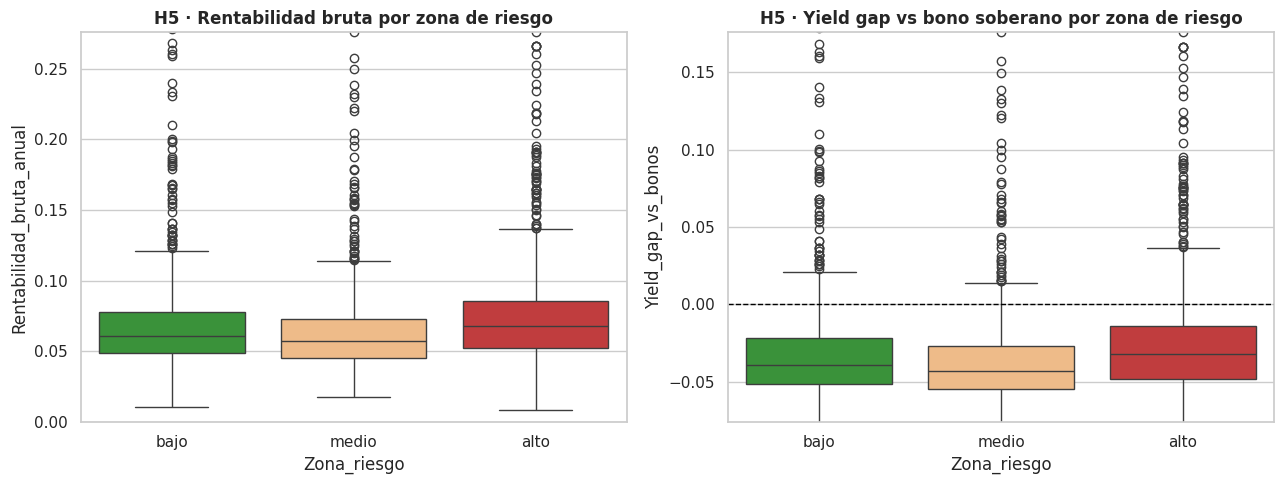

Medianas H5:
             Rentabilidad_bruta_anual  Yield_gap_vs_bonos  Precio_m2_USD
Zona_riesgo                                                             
bajo                            0.061              -0.039      2,719.309
medio                           0.057              -0.043      2,500.000
alto                            0.068              -0.032      2,205.882


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_v, x='Zona_riesgo', y='Rentabilidad_bruta_anual',
            order=['bajo','medio','alto'],
            palette=['#2ca02c','#ffbb78','#d62728'], ax=axes[0])
axes[0].set_ylim(0, df_v['Rentabilidad_bruta_anual'].quantile(0.99))
axes[0].set_title('H5 · Rentabilidad bruta por zona de riesgo')

sns.boxplot(data=df_v, x='Zona_riesgo', y='Yield_gap_vs_bonos',
            order=['bajo','medio','alto'],
            palette=['#2ca02c','#ffbb78','#d62728'], ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_ylim(df_v['Yield_gap_vs_bonos'].quantile(0.01),
                 df_v['Yield_gap_vs_bonos'].quantile(0.99))
axes[1].set_title('H5 · Yield gap vs bono soberano por zona de riesgo')

plt.tight_layout()
plt.show()

print('Medianas H5:')
print(df_v.groupby('Zona_riesgo')[['Rentabilidad_bruta_anual','Yield_gap_vs_bonos','Precio_m2_USD']]
      .median().reindex(['bajo','medio','alto']).round(4))

## 10. Síntesis de hallazgos

1. **Distribuciones**: Los precios y rentas son fuertemente asimétricos a derecha, con colas largas hacia valores altos. Esto implica que el análisis y los modelos posteriores deberán trabajar en escala logarítmica o con métodos robustos a outliers para no distorsionar las estimaciones.
2. **Tipologías y segmentos**: El inventario de ventas está concentrado en 3A y 2A, mientras que el de alquileres lo está en 2A y monoambientes. Esta asimetría entre oferta de venta y oferta de alquiler por tipología es una señal exploratoria que merece análisis formal en la etapa de hipótesis.
3. **Geografía**: El mapa de precio/m² reproduce el corredor norte clásico (Recoleta–Palermo–Belgrano), mientras que el mapa de rentabilidad bruta muestra un patrón diferente, más uniforme y con valores más altos en el sur y oeste. La dispersión espacial de renta/m² en alquileres sugiere la existencia de puntos con alta renta relativa fuera de las zonas premium, que podrían representar oportunidades de arbitraje.
4. **Subte** (H1): En la exploración visual, las distribuciones de precio/m² y rentabilidad bruta no muestran diferencias marcadas entre propiedades cercanas y lejanas al subte. Las medianas son similares entre grupos. Esta observación será testeada formalmente en el análisis de hipótesis.
5. **Tipología** (H2): Los boxplots muestran que los monoambientes y 2A tienen rentabilidades brutas medianas similares o levemente superiores a los 3A y 4+A, con paybacks más cortos. La dirección es consistente con H2 pero la diferencia es pequeña — requiere validación estadística.
6. **Parques** (H3): Las medianas de precio/m² muestran una diferencia de USD 170/m² entre propiedades cercanas (≤ 0,5 km) y lejanas (> 1,5 km) a un parque, siendo las lejanas levemente más caras. Este resultado va en contra de la dirección esperada por H3 y será analizado formalmente.
7. **A estrenar** (H4): Se observa un premium de precio/m² claro en propiedades a estrenar (~USD 3.153/m² vs ~USD 2.469/m² en usadas) y un payback más largo (23,7 vs 16,1 años). La rentabilidad bruta es menor para las propiedades nuevas (4,3% vs 6,2%). La dirección es consistente con H4 pero la muestra de propiedades a estrenar es muy pequeña (9 unidades), lo que limita la validación estadística.
8. **Riesgo** (H5): La zona de riesgo alto muestra una rentabilidad bruta mediana de 6,8% vs 6,1% en zona baja y 5,7% en zona media, con un yield gap menos negativo (-0,032 vs -0,039 y -0,043). La dirección sugiere que el mercado ofrece algo de compensación por riesgo, pero la diferencia es moderada. El test formal determinará si esta diferencia es estadísticamente significativa.